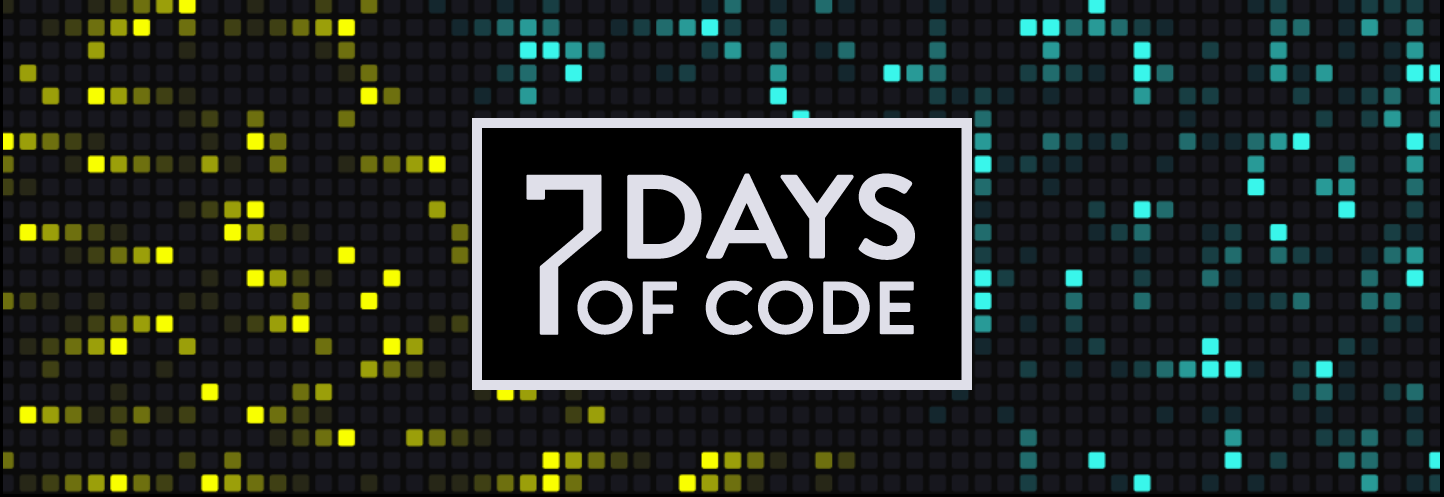

In [2]:
from IPython.display      import Image

Image('img/7daysofcode_logo.png')

# **Cota para Exercício da Atividade Parlamentar dos Senadores - CEAPS**
##  Tratamento e limpeza de dados

### 1. Importando Bibliotecas

In [3]:
#Bibliotecas de Manipulação e Tratamento de dados.
import numpy as np
import pandas as pd



#Bibliotecas de Visualização
import matplotlib.pyplot as plt
import seaborn as sns

import inflection

#Bibliotecas Auxiliares
from IPython.display      import Image
from IPython.core.display import HTML

import warnings
warnings.filterwarnings( 'ignore' )

#### 1.1 Funções Auxiliares

In [4]:
def jupyter_settings():
    %matplotlib inline
    
    plt.style.use( 'bmh' )
    plt.rcParams['figure.figsize'] = [12, 8]
    plt.rcParams['font.size'] = 24
    sns.set_palette("Reds") 
    
    display(HTML( '<style>.container { width:100% !important; }</style>'))
    pd.options.display.max_columns = None
    pd.options.display.max_rows = None
    pd.set_option( 'display.expand_frame_repr', False )
    
    sns.set()

In [5]:
jupyter_settings()

### 2. Carregando os dados

In [6]:
# Leitura dos datasets

dados_2022 = pd.read_csv('dados/despesa_ceaps_2022.csv', encoding = 'cp1252', sep=';', skiprows=1 )
dados_2021 = pd.read_csv('dados/despesa_ceaps_2021.csv', encoding = 'cp1252', sep=';', skiprows=1 )
dados_2020 = pd.read_csv('dados/despesa_ceaps_2020.csv', encoding = 'cp1252', sep=';', skiprows=1 )
dados_2019 = pd.read_csv('dados/despesa_ceaps_2019.csv', encoding = 'cp1252', sep=';', skiprows=1 )


#Concatenar os dados por ano
df = pd.concat([dados_2022,dados_2021,dados_2020,dados_2019], ignore_index=True)

In [7]:
total_linhas_raw = df.shape[0]
total_linhas_raw 

69333

##### ***Ideia 2: Removendo datas inválidas***

In [8]:
#Foi verificado na base de dados algumas datas inconsistentes, possivelmente por erro de digitação.
# Dados do ano de 2010, 2002, 0202, ou até mesmo com a data 31/02/2022 por exemplo. 
mascara = df['DATA'].str[-2:] == "02"
df.DATA[mascara]

12835    11/02/2002
12839    22/03/2002
12865    16/03/2002
12918    21/06/2002
12925    11/08/2002
14026    02/02/2002
16990    19/02/2002
18930    29/10/0202
43971    05/05/0202
45956    14/03/2002
Name: DATA, dtype: object

In [9]:
# Usar o método .str para acessar os últimos caracteres da coluna 'DATA' correspondentes ao ano
ano_2022 = df['DATA'].str[-4:] == "2022"
ano_2021 = df['DATA'].str[-4:] == "2021"
ano_2020 = df['DATA'].str[-4:] == "2020"
ano_2019 = df['DATA'].str[-4:] == "2019"

# Combinação das condições usando o operador de comparação |
mascara = ano_2022 | ano_2021 | ano_2020 | ano_2019

# Filtrar o DataFrame usando a máscara com o método .loc
df1 = df.loc[mascara]


In [10]:
dados_excluídos = total_linhas_raw - df1.shape[0]
dados_excluídos

183

### 3. Tratamento e Manipulação dos Dados

#### 3.1 Renomeando Colunas

In [11]:
df1.columns

Index(['ANO', 'MES', 'SENADOR', 'TIPO_DESPESA', 'CNPJ_CPF', 'FORNECEDOR',
       'DOCUMENTO', 'DATA', 'DETALHAMENTO', 'VALOR_REEMBOLSADO',
       'COD_DOCUMENTO'],
      dtype='object')

In [12]:
# Renomeando colunas para o formato SnakeCase (O melhor kk)

cols_old = ['ANO', 'MES', 'SENADOR', 'TIPO_DESPESA', 'CNPJ_CPF', 'FORNECEDOR',
       'DOCUMENTO', 'DATA', 'DETALHAMENTO', 'VALOR_REEMBOLSADO',
       'COD_DOCUMENTO']

snakecase = lambda x: inflection.underscore(x)
cols_new = list(map(snakecase,cols_old))

df1.columns = cols_new
df1.columns

Index(['ano', 'mes', 'senador', 'tipo_despesa', 'cnpj_cpf', 'fornecedor',
       'documento', 'data', 'detalhamento', 'valor_reembolsado',
       'cod_documento'],
      dtype='object')

#### 3.2 Dimensão dos Dados

In [13]:
# Dimensão do Dataset (Quantidade de Linhas e Colunas)
print(f'Número de Linhas: {df1.shape[0]}\nNúmero de Colunas: {df1.shape[1]}')

Número de Linhas: 69150
Número de Colunas: 11


#### 3.3 Tipo dos dados

In [14]:
# Tipo dos dados do dataset
df1.dtypes

ano                   int64
mes                   int64
senador              object
tipo_despesa         object
cnpj_cpf             object
fornecedor           object
documento            object
data                 object
detalhamento         object
valor_reembolsado    object
cod_documento         int64
dtype: object

In [15]:
df2 = df1.copy()

##### Convertendo tipo de dados

In [16]:
# # senador: Transformar os dados em letras minusculas
df2.senador = df2.senador.str.lower()

# # # tipo_despesa: Tokenização
# df2.tipo_despesa = df2.tipo_despesa.str.split(',')

# # cnpj_cpf: Remover os caracteres '.', '-', e '/' da coluna 'cnpj_cpf', converter para Int64
df2['cnpj_cpf'] = df2['cnpj_cpf'].replace(r'[./-]', '', regex=True)
df2.cnpj_cpf = df2.cnpj_cpf.astype(np.int64)

# # fornecedor: Transformar os dados em letras minusculas
df2.fornecedor = df2.fornecedor.str.lower()

# # data: Transformar object para datetime
df2.data = pd.to_datetime(df2.data, format='%d/%m/%Y')

# # valor_reembolsado: Trocar , por . , converter para float64
df2.valor_reembolsado = df2.valor_reembolsado.str.replace(',','.')
df2.valor_reembolsado = df2.valor_reembolsado.astype(np.float64)


In [17]:
df2.dtypes

ano                           int64
mes                           int64
senador                      object
tipo_despesa                 object
cnpj_cpf                      int64
fornecedor                   object
documento                    object
data                 datetime64[ns]
detalhamento                 object
valor_reembolsado           float64
cod_documento                 int64
dtype: object

#### 3.4 Checagem dos Valores Nulos

In [18]:
# Checagem dos valores nulos em cada coluna
df2.isnull().sum()

ano                      0
mes                      0
senador                  0
tipo_despesa             0
cnpj_cpf                 0
fornecedor               0
documento             2955
data                     0
detalhamento         30682
valor_reembolsado        0
cod_documento            0
dtype: int64

#####  Tratamentos dos dados nulos

In [19]:
# Neste primeiro ciclo, irei substituir os valores nulos por 0
df2.documento.fillna(0, inplace=True)

df2.detalhamento.fillna(0,inplace=True)

In [20]:
#Verificar novamente
df2.isnull().sum()

ano                  0
mes                  0
senador              0
tipo_despesa         0
cnpj_cpf             0
fornecedor           0
documento            0
data                 0
detalhamento         0
valor_reembolsado    0
cod_documento        0
dtype: int64

### 4. Análise Descritiva dos Dados

In [21]:
# Primeiramente vamos separar os dados em variaveis categoricas e variaveis numericas
var_num = df2.select_dtypes(include=['int64','float64'])

var_cat = df2.select_dtypes(exclude=['int64','float64', 'datetime64[ns]'])

##### ***Variáveis Categoricas***

In [22]:
# Medidas de Tendencia Central
ctd1 = var_num.describe()

# Medidas de Dispersão
d1 = pd.DataFrame(var_num.apply(lambda x:x.max()-x.min())).T

d2 = pd.DataFrame(var_num.apply(lambda x:x.skew())).T

d3 = pd.DataFrame(var_num.apply(lambda x: x.kurtosis())).T

# Concatenação das medidas estatisticas
medidas = pd.concat([ctd1,d1,d2,d3]).T.reset_index()

# Renomear colunas
medidas.columns = ['variaveis','count','mean','std','min','25%','median','75%','max','range','skew','kustosis']

medidas

,variaveis,count,mean,std,min,25%,median,75%,max,range,skew,kustosis
0,ano,69150.0,2.020415e+03,1.161351e+00,2.019000e+03,2.019000e+03,2.020000e+03,2.021000e+03,2.022000e+03,3.000000e+00,0.072802,-1.456611
1,mes,69150.0,6.586334e+00,3.363423e+00,1.000000e+00,4.000000e+00,7.000000e+00,9.000000e+00,1.200000e+01,1.100000e+01,-0.021673,-1.196184
2,cnpj_cpf,69150.0,1.989103e+13,1.966198e+13,2.703195e+08,6.028059e+12,1.513963e+13,2.718928e+13,9.858792e+13,9.858765e+13,1.798101,3.400561
3,valor_reembolsado,69150.0,1.410331e+03,3.094063e+03,1.000000e-02,1.580000e+02,4.251450e+02,1.568275e+03,1.200000e+05,1.200000e+05,8.810099,147.931973
4,cod_documento,69150.0,2.153668e+06,2.252238e+04,2.112846e+06,2.134419e+06,2.153700e+06,2.172868e+06,2.198297e+06,8.545100e+04,-0.005283,-1.165363


<Figure size 3000x6000 with 0 Axes>

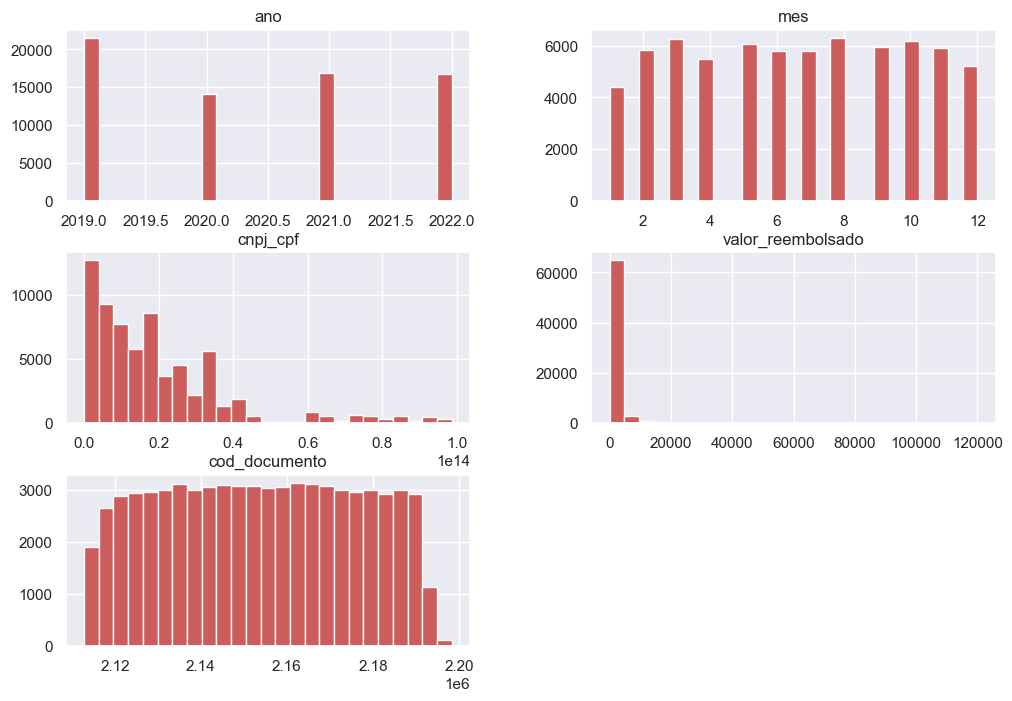

In [23]:
# Gráficos demonstando os dados das variáveis numéricas
plt.figure(figsize = (30,60))
var_num.hist(bins= 25, color= 'indianred');

##### ***Variáveis Categóricas*** 

In [24]:
# Conta a quantidade de valores únicos em cada coluna de um DataFrame com variáveis categóricas.
var_cat.apply(lambda x: x.unique().shape[0])

senador           153
tipo_despesa        7
fornecedor       8318
documento       55261
detalhamento    22400
dtype: int64

<Axes: xlabel='senador', ylabel='count'>

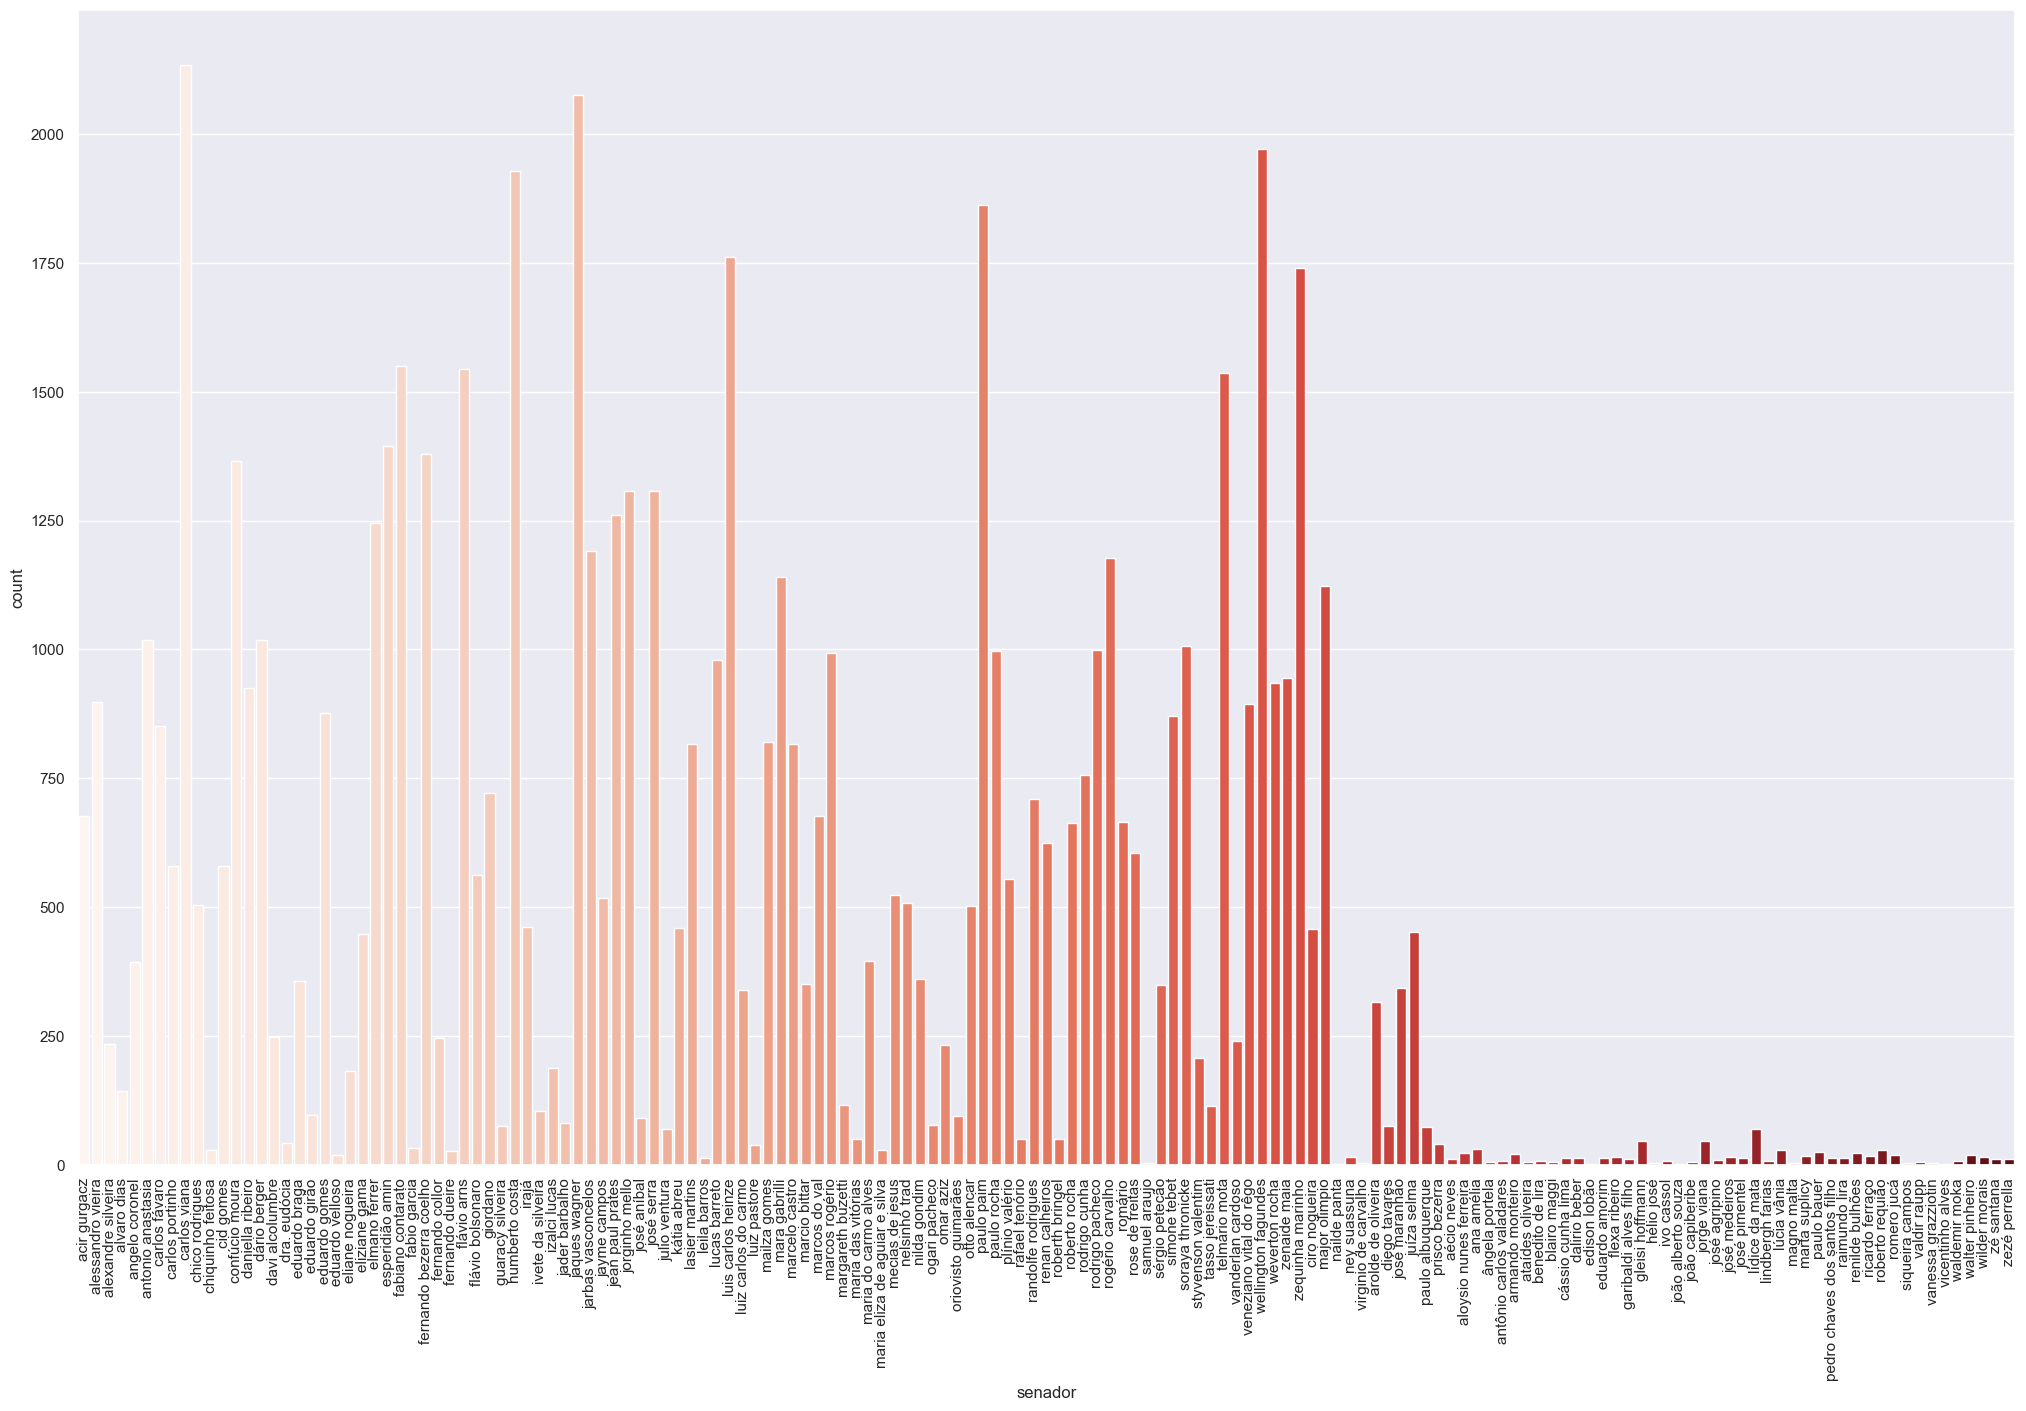

In [41]:
# Plota gráficos de barras da contagem de cada senador que reembolsaram o valor
plt.figure(figsize=(25,15))
plt.xticks(rotation=90)
sns.countplot( x=df2.senador, data=df2, palette = 'Reds')

<Axes: xlabel='tipo_despesa', ylabel='count'>

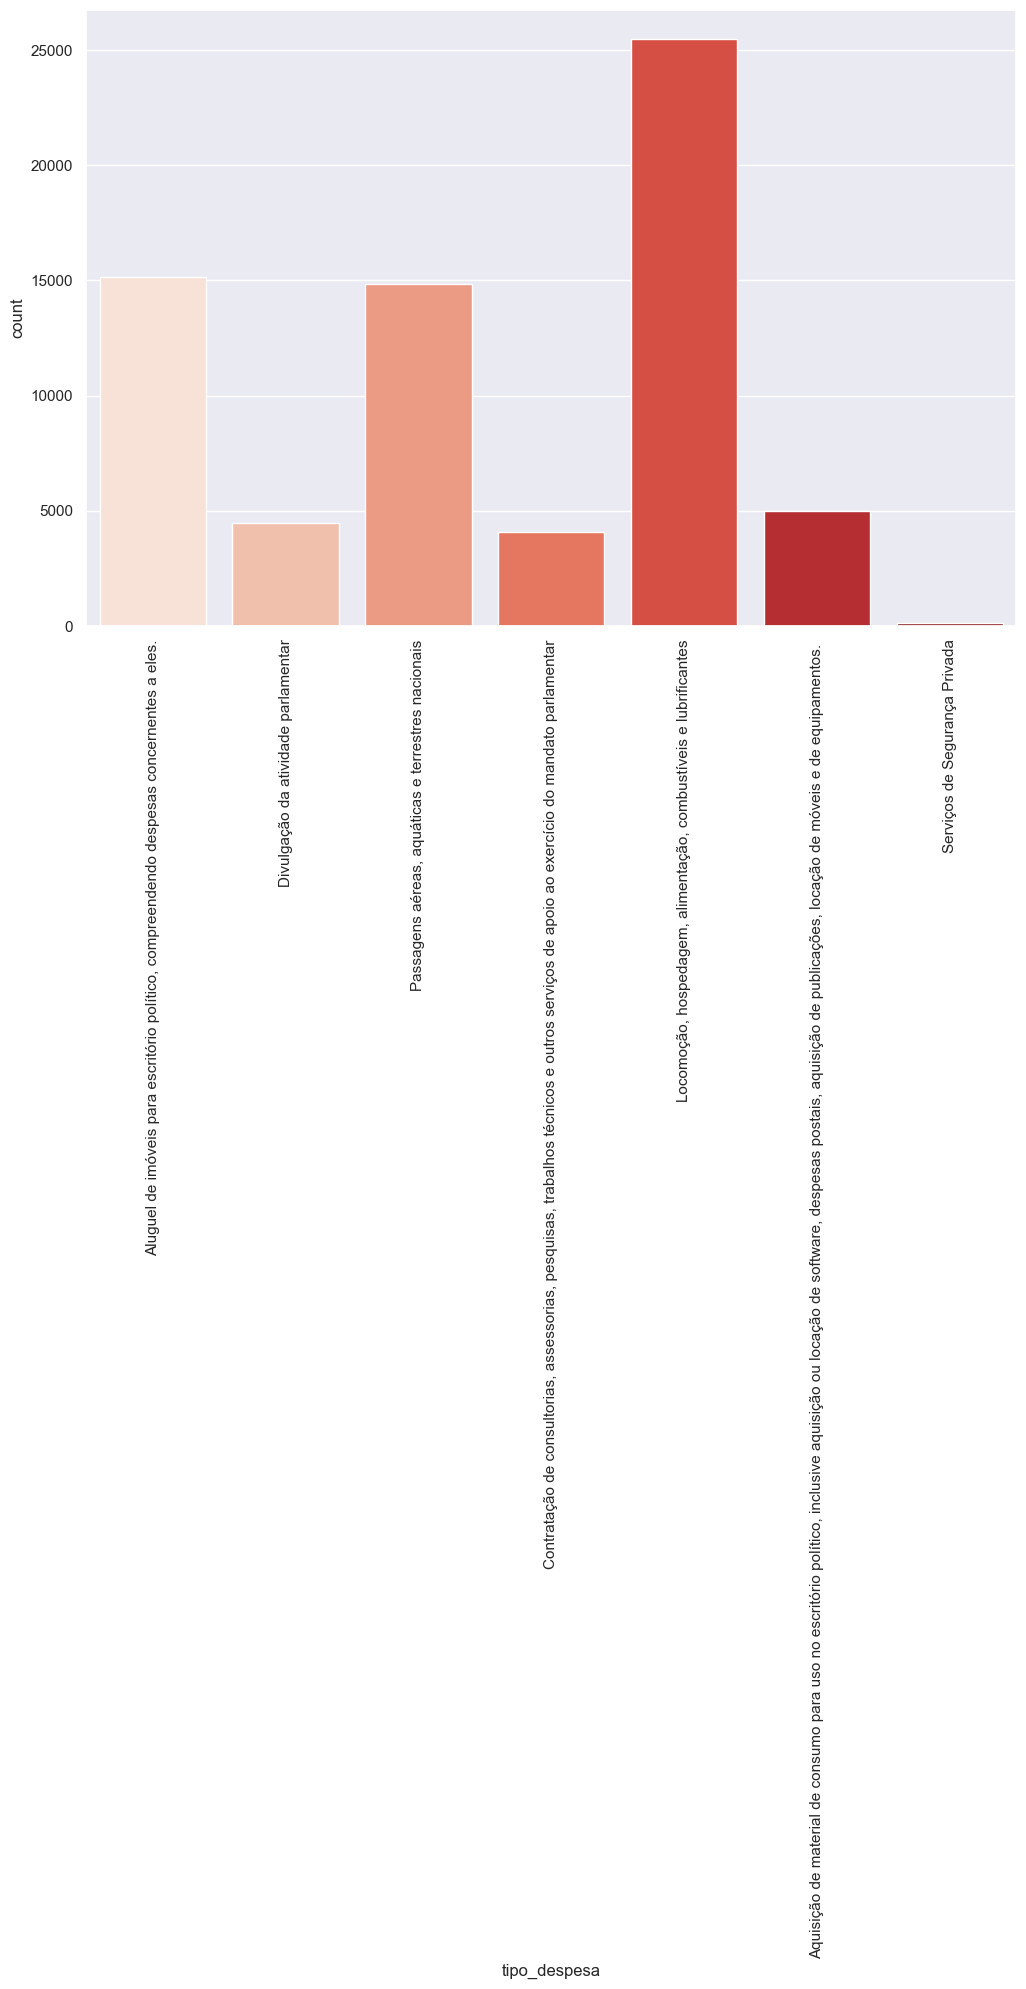

In [37]:
plt.xticks(rotation=90)
sns.countplot( x=df2.tipo_despesa, data=df2, palette = 'Reds')
